In [1]:
import os
import shutil
import random
import logging
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

# --- Configuration ---
# Dataset Paths
SOURCE_DATA_DIR = 'images/'
BASE_DATA_SPLIT_DIR = 'data_split/'
TRAIN_DIR = os.path.join(BASE_DATA_SPLIT_DIR, 'train')
VAL_DIR = os.path.join(BASE_DATA_SPLIT_DIR, 'validation')
TEST_DIR = os.path.join(BASE_DATA_SPLIT_DIR, 'test')

# Split Ratios
TRAIN_RATIO = 0.84
VAL_RATIO = 0.08
TEST_RATIO = 0.08

# Model Parameters
IMG_SIZE = (224, 224) # ResNet50 size
BATCH_SIZE = 32
LEARNING_RATE = 0.001
MODEL_SAVE_PATH = 'kuih_recognition_model_resnet50.keras'
EPOCHS_TO_TRAIN = 20

In [2]:
def split_dataset(source, destination, train_r, val_r, test_r, force_resplit=False):
    """
    Splits images from source into train/val/test directories in destination.
    """
    if not os.path.exists(source):
        logger.error(f"Source directory '{source}' not found. Please ensure your 'images' folder exists.")
        return
    if os.path.exists(destination) and not force_resplit:
        logger.info(f"Split directory '{destination}' already exists. Skipping re-split.")
        return
    logger.info(f"Starting dataset split from '{source}' to '{destination}'...")
    for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
        os.makedirs(d, exist_ok=True)
    class_counts = defaultdict(lambda: {'train': 0, 'val': 0, 'test': 0, 'total': 0})
    for class_name in os.listdir(source):
        class_source_path = os.path.join(source, class_name)
        if not os.path.isdir(class_source_path):
            continue
        for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
            os.makedirs(os.path.join(d, class_name), exist_ok=True)
        files = [f for f in os.listdir(class_source_path) if os.path.isfile(os.path.join(class_source_path, f))]
        if not files:
            continue
        random.shuffle(files)
        total = len(files)
        class_counts[class_name]['total'] = total
        train_end = int(total * train_r)
        val_end = train_end + int(total * val_r)
        splits = {
            'train': (files[:train_end], TRAIN_DIR),
            'val': (files[train_end:val_end], VAL_DIR),
            'test': (files[val_end:], TEST_DIR)
        }
        for split_name, (split_files, split_dir) in splits.items():
            for file_name in split_files:
                src = os.path.join(class_source_path, file_name)
                dst = os.path.join(split_dir, class_name, file_name)
                try:
                    shutil.copy2(src, dst)
                    class_counts[class_name][split_name] += 1
                except Exception as e:
                    logger.error(f"Error copying {file_name}: {e}")
    logger.info("\\n--- Data Split Summary ---")
    for cls, counts in class_counts.items():
         logger.info(f"{cls:<15} | Total: {counts['total']:<4} | Train: {counts['train']:<4} | Val: {counts['val']:<4} | Test: {counts['test']:<4}")
    logger.info("--------------------------")

# Run the split
split_dataset(SOURCE_DATA_DIR, BASE_DATA_SPLIT_DIR, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, force_resplit=False)

INFO: Split directory 'data_split/' already exists. Skipping re-split.


In [3]:
logger.info("Setting up data generators from split directories...")
# Generator for Training (with augmentation)
datagen_train = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
# Generator for Validation and Testing (only preprocessing)
datagen_val_test = ImageDataGenerator(preprocessing_function=preprocess_input)

if not os.path.exists(TRAIN_DIR):
    logger.error(f"Training directory not found: {TRAIN_DIR}. Run split_dataset.")
else:
    train_generator = datagen_train.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )
    validation_generator = datagen_val_test.flow_from_directory(
        VAL_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    test_generator = datagen_val_test.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=1,
        class_mode='categorical',
        shuffle=False
    )
    
    num_classes = train_generator.num_classes
    class_labels = list(train_generator.class_indices.keys())
    logger.info(f"Detected {num_classes} classes: {class_labels}")

INFO: Setting up data generators from split directories...


Found 1023 images belonging to 11 classes.
Found 95 images belonging to 11 classes.
Found 109 images belonging to 11 classes.


INFO: Detected 11 classes: ['Akok', 'Cek Mek Molek', 'Ketayap', 'Kole Kacang', 'Kuih Bakar', 'Kuih Lapis', 'Kuih Lompang', 'Kuih Qasidah', 'Onde-onde', 'Pulut Sekaya', 'Seri Muka']


In [4]:
logger.info(f"Building model for {num_classes} classes using ResNet50 base...")
base_model = ResNet50(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False
logger.info("ResNet50 base model loaded and layers frozen.")

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
logger.info("Custom top layers added.")

optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

INFO: Building model for 11 classes using ResNet50 base...
INFO: ResNet50 base model loaded and layers frozen.
INFO: Custom top layers added.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,403 (90.99 MB)

 Trainable params: 263,691 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [5]:
logger.info(f"Starting model training for {EPOCHS_TO_TRAIN} epochs...")
steps_per_epoch = max(1, train_generator.samples // BATCH_SIZE)
validation_steps = max(1, validation_generator.samples // BATCH_SIZE)

checkpoint = ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=50, # Using 50 with early stopping
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=[checkpoint, early_stop, reduce_lr]
)
logger.info("Model training completed.")

INFO: Starting model training for 20 epochs...
C:\Users\rahim\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2505 - loss: 2.7495
Epoch 1: val_accuracy improved from -inf to 0.82812, saving model to kuih_recognition_model_resnet50.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 271s 8s/step - accuracy: 0.2535 - loss: 2.7322 - val_accuracy: 0.8281 - val_loss: 0.9976 - learning_rate: 0.0010
Epoch 2/50
 1/31 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.4688 - loss: 1.6265

C:\Users\rahim\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.82812 to 0.84375, saving model to kuih_recognition_model_resnet50.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 501ms/step - accuracy: 0.4688 - loss: 1.6265 - val_accuracy: 0.8438 - val_loss: 0.9626 - learning_rate: 0.0010
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5755 - loss: 1.3075
Epoch 3: val_accuracy improved from 0.84375 to 0.90625, saving model to kuih_recognition_model_resnet50.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 235s 8s/step - accuracy: 0.5767 - loss: 1.3031 - val_accuracy: 0.9062 - val_loss: 0.4452 - learning_rate: 0.0010
Epoch 4/50
 1/31 ━━━━━━━━━━━━━━━━━━━━ 1:42 3s/step - accuracy: 0.7097 - loss: 0.7758
Epoch 4: val_accuracy did not improve from 0.90625
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 512ms/step - accuracy: 0.7097 - loss: 0.7758 - val_accuracy: 0.8906 - val_loss: 0.4535 - learning_rate: 0.0010
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7340 - loss: 0.8548
Epoch 5: val_accuracy did not improve from 0.90625
31

INFO: Model training completed.


INFO: Evaluating model on the test set...


109/109 ━━━━━━━━━━━━━━━━━━━━ 23s 207ms/step - accuracy: 0.9837 - loss: 0.0843


INFO: Test Loss: 0.1053
INFO: Test Accuracy: 0.9725


109/109 ━━━━━━━━━━━━━━━━━━━━ 29s 228ms/step


INFO: \n--- Classification Report ---
INFO: \n--- Confusion Matrix ---


               precision    recall  f1-score   support

         Akok       1.00      1.00      1.00         9
Cek Mek Molek       1.00      1.00      1.00         4
      Ketayap       0.89      1.00      0.94        16
  Kole Kacang       1.00      0.90      0.95        10
   Kuih Bakar       1.00      1.00      1.00         9
   Kuih Lapis       1.00      1.00      1.00         9
 Kuih Lompang       1.00      1.00      1.00        12
 Kuih Qasidah       1.00      1.00      1.00         4
    Onde-onde       1.00      0.86      0.92        14
 Pulut Sekaya       0.91      1.00      0.95        10
    Seri Muka       1.00      1.00      1.00        12

     accuracy                           0.97       109
    macro avg       0.98      0.98      0.98       109
 weighted avg       0.98      0.97      0.97       109



INFO: Confusion matrix saved to 'confusion_matrix_resnet50.png'


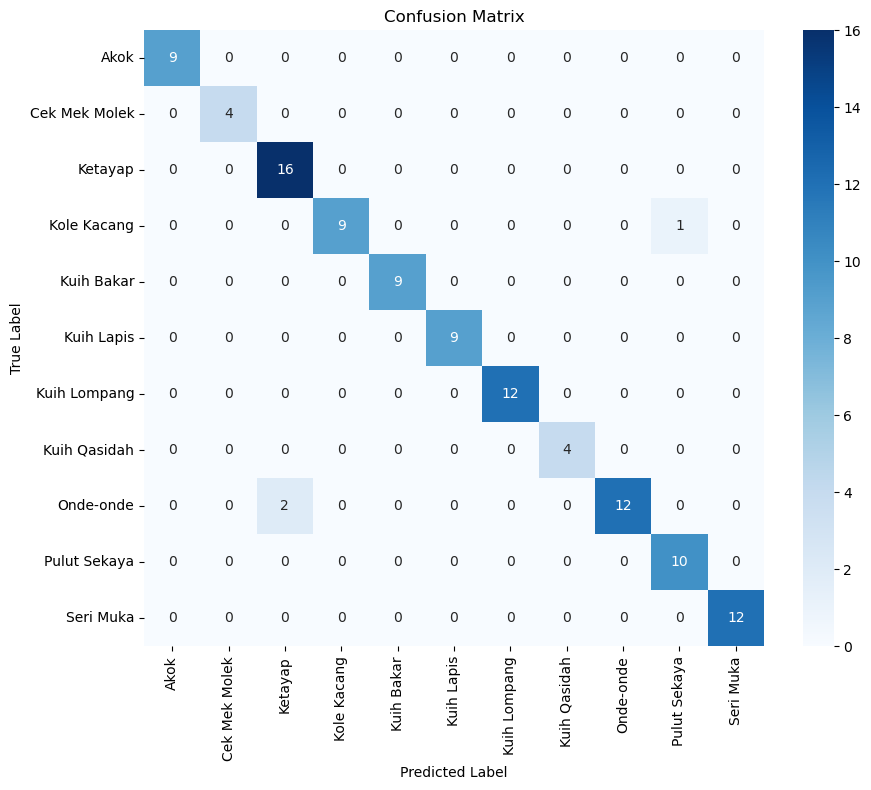

In [6]:
logger.info("Evaluating model on the test set...")
test_generator.reset()
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples, verbose=1)
logger.info(f"Test Loss: {test_loss:.4f}")
logger.info(f"Test Accuracy: {test_acc:.4f}")

test_generator.reset()
predictions = model.predict(test_generator, steps=test_generator.samples)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
target_names = list(test_generator.class_indices.keys())

logger.info("\\n--- Classification Report ---")
report = classification_report(true_classes, predicted_classes, target_names=target_names, zero_division=0)
print(report)

logger.info("\\n--- Confusion Matrix ---")
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix_resnet50.png')
logger.info("Confusion matrix saved to 'confusion_matrix_resnet50.png'")